# Runoff Forecasting Project - Group 9

**Members:** Alan Ray · Zach Shotwell · Miguel Moreno Coin  
**Course:** Artificial Intelligence, Appalachian State University  
**GitHub:** https://github.com/zachshotwell/AI-FinalProject-GroupSCR

This notebook builds an end-to-end deep learning post-processing pipeline for short-range runoff forecasting.  
The goal is to improve NOAA National Water Model (NWM) streamflow forecasts by learning forecast residuals relative to USGS observations, then reconstructing corrected forecasts for lead times of 1–18 hours.

## Setup

In [2]:
!git clone https://github.com/zachshotwell/AI-FinalProject-GroupSCR
%cd AI-FinalProject-GroupSCR
%cd RunoffForecastingProject
!ls

Cloning into 'AI-FinalProject-GroupSCR'...
remote: Enumerating objects: 2098, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 2098 (delta 13), reused 4 (delta 2), pack-reused 2071 (from 2)
Receiving objects: 100% (2098/2098), 59.02 MiB | 26.20 MiB/s, done.
Resolving deltas: 100% (1672/1672), done.
/content/AI-FinalProject-GroupSCR
/content/AI-FinalProject-GroupSCR/RunoffForecastingProject
 data
'Improved runoff forecasting performance through error predictions using a deep-learning approach.pdf'
 README.md
 RunoffForcastingProject.pdf
 RunoffForecasting.ipynb


In [7]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.19.0
GPU: []


## Data Reconnaissance

Before building the loader, we inspect one USGS observation file and one monthly
NWM forecast file from each station folder to confirm the raw schema and time layout.

This check is used to verify:
- forecast layout (long vs. wide)
- column names and dtypes
- datetime fields and time coverage
- sampling cadence
- rough streamflow magnitude and likely units

This section is exploratory only; final cleaning, alignment, and unit handling are done in the loader section.

In [4]:
DATA_ROOT = Path("data")

# NWM reach (folder name) -> paired USGS gauge
STATIONS = {
    "20380357": "09520500",
    "21609641": "11266500",
}

def find_files(folder: Path):
    """Return the single USGS CSV and the monthly NWM CSVs for one station folder."""
    csvs = sorted(folder.glob("*.csv"))
    usgs_files = [f for f in csvs if "Strt" in f.name and "EndAt" in f.name]
    nwm_files = [f for f in csvs if f.name.startswith("streamflow_")]

    if len(usgs_files) != 1:
        raise ValueError(
            f"Expected exactly 1 USGS file in {folder}, "
            f"found {len(usgs_files)}: {[f.name for f in usgs_files]}"
        )

    return usgs_files[0], nwm_files

def inspect_datetime_cols(df: pd.DataFrame):
    """Parse likely datetime columns and return basic coverage info."""
    candidates = [
        c for c in df.columns
        if any(key in c.lower() for key in ["date", "time"])
    ]

    found = []
    for c in candidates:
        try:
            fmt = "%Y-%m-%d_%H:%M:%S" if "model_" in c else None
            parsed = pd.to_datetime(df[c], format=fmt, utc=True)
            diffs = parsed.sort_values().diff().dropna()
            found.append(
                {
                    "col": c,
                    "start": parsed.min(),
                    "end": parsed.max(),
                    "n_unique": parsed.nunique(),
                    "median_delta": diffs.median() if not diffs.empty else "N/A",
                }
            )
        except Exception:
            continue

    return found

def report(df: pd.DataFrame, label: str, n: int = 3) -> None:
    print(f"\n--- {label} ---")
    print(f"shape:   {df.shape}")
    print(f"columns: {list(df.columns)}")

    print("\ndtypes:")
    print(df.dtypes.to_string())

    print(f"\nhead({n}):")
    print(df.head(n).to_string())

    print(f"\ntail({n}):")
    print(df.tail(n).to_string())

    dt_info = inspect_datetime_cols(df)
    if dt_info:
        print("\ndatetime columns:")
        for info in dt_info:
            print(f"  {info['col']}")
            print(f"    range:        {info['start']}  ->  {info['end']}")
            print(f"    n unique:     {info['n_unique']}")
            print(f"    median delta: {info['median_delta']}")
    else:
        print("\nNo datetime columns parsed.")

    # Exclude obvious ID/version columns from rough magnitude checks
    value_cols = [
        c for c in df.select_dtypes(include="number").columns
        if "id" not in c.lower() and "version" not in c.lower()
    ]
    if value_cols:
        print("\nnumeric value summary:")
        print(df[value_cols].describe().T[["min", "50%", "max"]].to_string())

        max_val = df[value_cols].max(numeric_only=True).max()
        if max_val > 0:
            hint = "likely cfs" if max_val > 1000 else "likely cms"
            print(f"  -> rough unit hint from magnitude: {hint}")

def classify_format(df: pd.DataFrame) -> str:
    n_cols = df.shape[1]
    if n_cols <= 5:
        return f"likely LONG (one row per issue/lead pair) -- {n_cols} cols"
    if 18 <= n_cols <= 25:
        return f"likely WIDE (one row per issue time, ~18 lead columns) -- {n_cols} cols"
    return f"ambiguous layout -- {n_cols} cols"

def main() -> None:
    for nwm_id, usgs_id in STATIONS.items():
        folder = DATA_ROOT / nwm_id
        bar = "=" * 72

        print(f"\n{bar}")
        print(f"Station folder: {folder}   (paired USGS gauge: {usgs_id})")
        print(bar)

        usgs_file, nwm_files = find_files(folder)

        print(f"USGS file:  {usgs_file.name}")
        print(f"NWM files:  {len(nwm_files)} found")
        if nwm_files:
            print(f"  first: {nwm_files[0].name}")
            print(f"  last:  {nwm_files[-1].name}")

        usgs_df = pd.read_csv(usgs_file)
        report(usgs_df, f"USGS observations -- {usgs_id}")

        if nwm_files:
            nwm_df = pd.read_csv(nwm_files[0])
            report(nwm_df, f"NWM forecast -- {nwm_files[0].name}")
            print(f"\nformat hint: {classify_format(nwm_df)}")

main()


Station folder: data/20380357   (paired USGS gauge: 09520500)
USGS file:  09520500_Strt_2021-04-20_EndAt_2023-04-21.csv
NWM files:  25 found
  first: streamflow_20380357_202104.csv
  last:  streamflow_20380357_202304.csv

--- USGS observations -- 09520500 ---
shape:   (70089, 3)
columns: ['DateTime', 'USGSFlowValue', 'USGS_GageID']

dtypes:
DateTime          object
USGSFlowValue    float64
USGS_GageID       object

head(3):
                    DateTime  USGSFlowValue USGS_GageID
0  2021-04-20 07:00:00+00:00           0.18           A
1  2021-04-20 07:15:00+00:00           0.18           A
2  2021-04-20 07:30:00+00:00           0.19           A

tail(3):
                        DateTime  USGSFlowValue USGS_GageID
70086  2023-04-22 06:15:00+00:00           0.15           A
70087  2023-04-22 06:30:00+00:00           0.15           A
70088  2023-04-22 06:45:00+00:00           0.15           A

datetime columns:
  DateTime
    range:        2021-04-20 07:00:00+00:00  ->  2023-04-22 06:45:0

## Data Preparation

This section converts the raw NWM forecast files and USGS observations into a
single tidy hourly table for each station. The main steps are:
- parse NWM issue times and valid times
- resample USGS observations from 15-minute to hourly cadence
- align NWM forecasts with USGS observations on `valid_time`
- compute forecast residuals as `error = usgs_q - nwm_q`

The resulting tidy tables are saved for downstream splitting, windowing, model
training, and evaluation.

In [5]:
# NWM uses an underscore between date and time -- explicit format avoids
# the dateutil row-by-row fallback which is ~50x slower on 300k+ rows.
NWM_DT_FMT = "%Y-%m-%d_%H:%M:%S"

STATIONS = {
    "20380357": "09520500",  # small headwater stream
    "21609641": "11266500",  # larger river
}

# ---------- USGS ----------------------------------------------------------- #

def load_usgs(usgs_file: Path, unit_factor: float = 1.0) -> pd.Series:
    """
    Load a USGS observation CSV and return an hourly Series of streamflow
    indexed by timezone-aware UTC timestamp.

    The raw extract is at 15-minute cadence; we subsample at the top of each
    hour (minute == 0) to match NWM's hourly grid, rather than averaging --
    NWM forecasts represent instantaneous values, so we do the same for obs.
    """
    df = pd.read_csv(usgs_file, parse_dates=["DateTime"])
    df = df[["DateTime", "USGSFlowValue"]].rename(
        columns={"DateTime": "valid_time", "USGSFlowValue": "usgs_q"}
    )
    df["valid_time"] = pd.to_datetime(df["valid_time"], utc=True)
    df = df.set_index("valid_time").sort_index()

    # asfreq picks the value at exactly each hour mark; missing -> NaN.
    hourly = df["usgs_q"].asfreq("h")
    return hourly * unit_factor

# ---------- NWM ------------------------------------------------------------ #

def _load_one_nwm_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["init_time"] = pd.to_datetime(
        df["model_initialization_time"], format=NWM_DT_FMT, utc=True
    )
    df["valid_time"] = pd.to_datetime(
        df["model_output_valid_time"], format=NWM_DT_FMT, utc=True
    )
    df["lead_h"] = (
        (df["valid_time"] - df["init_time"]).dt.total_seconds() // 3600
    ).astype(int)
    df = df.rename(columns={"streamflow_value": "nwm_q"})
    return df[["init_time", "valid_time", "lead_h", "nwm_q"]]

def load_nwm_station(station_folder: Path) -> pd.DataFrame:
    """Concatenate all 25 monthly NWM files for one station, dedupe overlaps."""
    files = sorted(station_folder.glob("streamflow_*.csv"))
    if not files:
        raise FileNotFoundError(f"No NWM files found in {station_folder}")
    parts = [_load_one_nwm_file(f) for f in files]
    nwm = pd.concat(parts, ignore_index=True)
    # If two consecutive monthly files overlap at the boundary, the same
    # (init_time, lead_h) pair will appear twice -- keep the first.
    nwm = nwm.drop_duplicates(subset=["init_time", "lead_h"], keep="first")
    nwm = nwm.sort_values(["init_time", "lead_h"]).reset_index(drop=True)
    return nwm

# ---------- Join ----------------------------------------------------------- #

def build_station_df(
    station_folder: str | Path,
    usgs_unit_factor: float = 1.0,
) -> pd.DataFrame:
    """
    Build the tidy [valid_time, init_time, lead_h, nwm_q, usgs_q, error] frame
    for one station.

    Args:
        station_folder: path to e.g. "data/20380357"
        usgs_unit_factor: multiplier applied to USGS values. Use 0.0283168
            if USGS is in cfs and you want everything in cms.
    """
    station_folder = Path(station_folder)

    # find USGS file by naming pattern
    usgs_files = [
        f for f in station_folder.glob("*.csv")
        if "Strt" in f.name and "EndAt" in f.name
    ]
    if len(usgs_files) != 1:
        raise ValueError(
            f"Expected 1 USGS file in {station_folder}, found "
            f"{[f.name for f in usgs_files]}"
        )

    usgs_hourly = load_usgs(usgs_files[0], unit_factor=usgs_unit_factor)
    nwm = load_nwm_station(station_folder)

    # left-join USGS onto NWM by valid_time. Missing obs -> NaN in usgs_q.
    df = nwm.merge(
        usgs_hourly.rename("usgs_q"),
        left_on="valid_time",
        right_index=True,
        how="left",
    )
    df["error"] = df["usgs_q"] - df["nwm_q"]

    return df[["valid_time", "init_time", "lead_h", "nwm_q", "usgs_q", "error"]]

# ---------- Reporting ------------------------------------------------------ #

def summarize(df: pd.DataFrame, label: str) -> None:
    print(f"\n{'='*72}\n{label}\n{'='*72}")
    print(f"rows:           {len(df):,}")
    print(f"unique inits:   {df['init_time'].nunique():,}")
    print(f"lead_h range:   {df['lead_h'].min()}..{df['lead_h'].max()}")
    print(f"valid_time:     {df['valid_time'].min()}  ->  {df['valid_time'].max()}")
    print(f"missing usgs_q: {df['usgs_q'].isna().sum():,} "
          f"({df['usgs_q'].isna().mean():.1%})")

    # NWM-vs-obs sanity at lead 1
    lead1 = df[df["lead_h"] == 1].dropna()
    if not lead1.empty:
        print(f"\nat lead_h=1 (n={len(lead1):,} aligned rows):")
        print(f"  nwm_q   median={lead1['nwm_q'].median():7.3f}  max={lead1['nwm_q'].max():8.2f}")
        print(f"  usgs_q  median={lead1['usgs_q'].median():7.3f}  max={lead1['usgs_q'].max():8.2f}")
        print(f"  error   median={lead1['error'].median():+7.3f}  mean={lead1['error'].mean():+7.3f}")
        ratio = lead1["nwm_q"].median() / max(lead1["usgs_q"].median(), 1e-9)
        print(f"  nwm/usgs median ratio: {ratio:.2f}  "
              f"(>>1 or <<1 suggests a unit mismatch)")

def main() -> None:
    data_root = Path("data")
    for nwm_id, usgs_id in STATIONS.items():
        df = build_station_df(data_root / nwm_id)
        summarize(df, f"Station {nwm_id} (USGS {usgs_id})")
        # save for downstream use
        out = data_root / nwm_id / f"tidy_{nwm_id}.parquet"
        df.to_parquet(out)
        print(f"\nwrote: {out}")

main()



Station 20380357 (USGS 09520500)
rows:           315,789
unique inits:   17,544
lead_h range:   1..18
valid_time:     2021-04-21 01:00:00+00:00  ->  2023-04-22 17:00:00+00:00
missing usgs_q: 1,164 (0.4%)

at lead_h=1 (n=17,483 aligned rows):
  nwm_q   median=  3.930  max=  207.66
  usgs_q  median=  0.240  max=    4.08
  error   median= -3.700  mean= -4.840
  nwm/usgs median ratio: 16.37  (>>1 or <<1 suggests a unit mismatch)

wrote: data/20380357/tidy_20380357.parquet

Station 21609641 (USGS 11266500)
rows:           315,789
unique inits:   17,544
lead_h range:   1..18
valid_time:     2021-04-21 01:00:00+00:00  ->  2023-04-22 17:00:00+00:00
missing usgs_q: 18,372 (5.8%)

at lead_h=1 (n=16,527 aligned rows):
  nwm_q   median=  6.300  max=  129.28
  usgs_q  median=  7.080  max=  133.66
  error   median= +0.030  mean= +0.282
  nwm/usgs median ratio: 0.89  (>>1 or <<1 suggests a unit mismatch)

wrote: data/21609641/tidy_21609641.parquet


## Exploratory Data Analysis

This section visualizes the hourly lead-1 series for each station after alignment.
The goals are to:
- compare raw NWM forecasts against USGS observations
- inspect the residual series `error = usgs_q - nwm_q`
- summarize missing observations before imputation
- examine residual autocorrelation to assess whether a short input window such as `L = 6` is reasonable

Train, validation, and test periods are shaded to make the chronological split visible.

Missing-data summary (raw, before forward-fill):
  station 20380357: 61 / 17,544 hours missing USGS (0.3%)
  station 21609641: 1,017 / 17,544 hours missing USGS (5.8%)



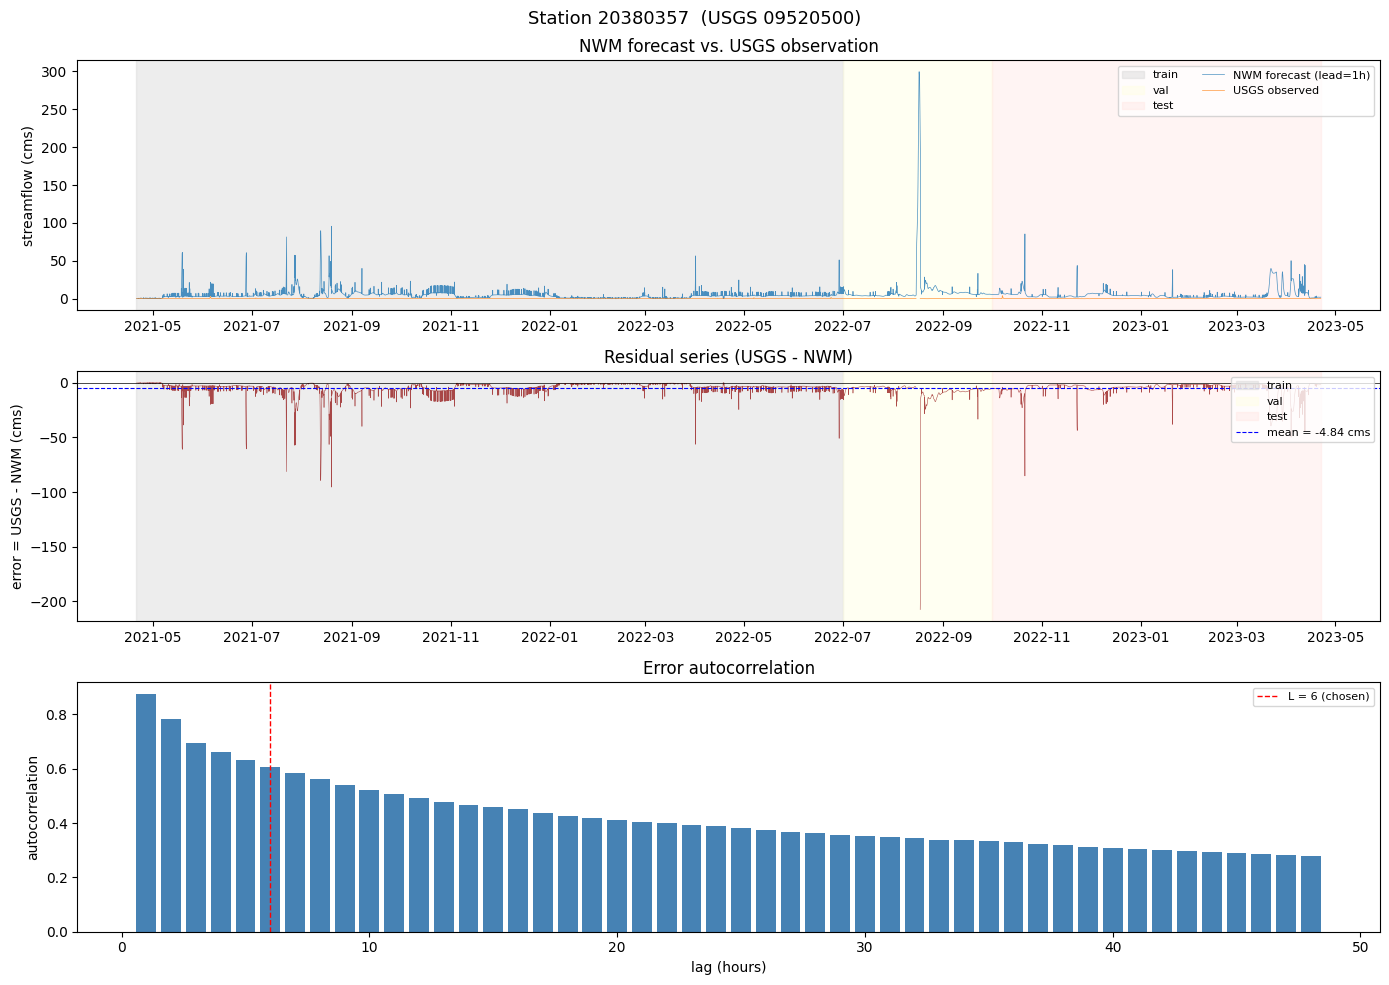

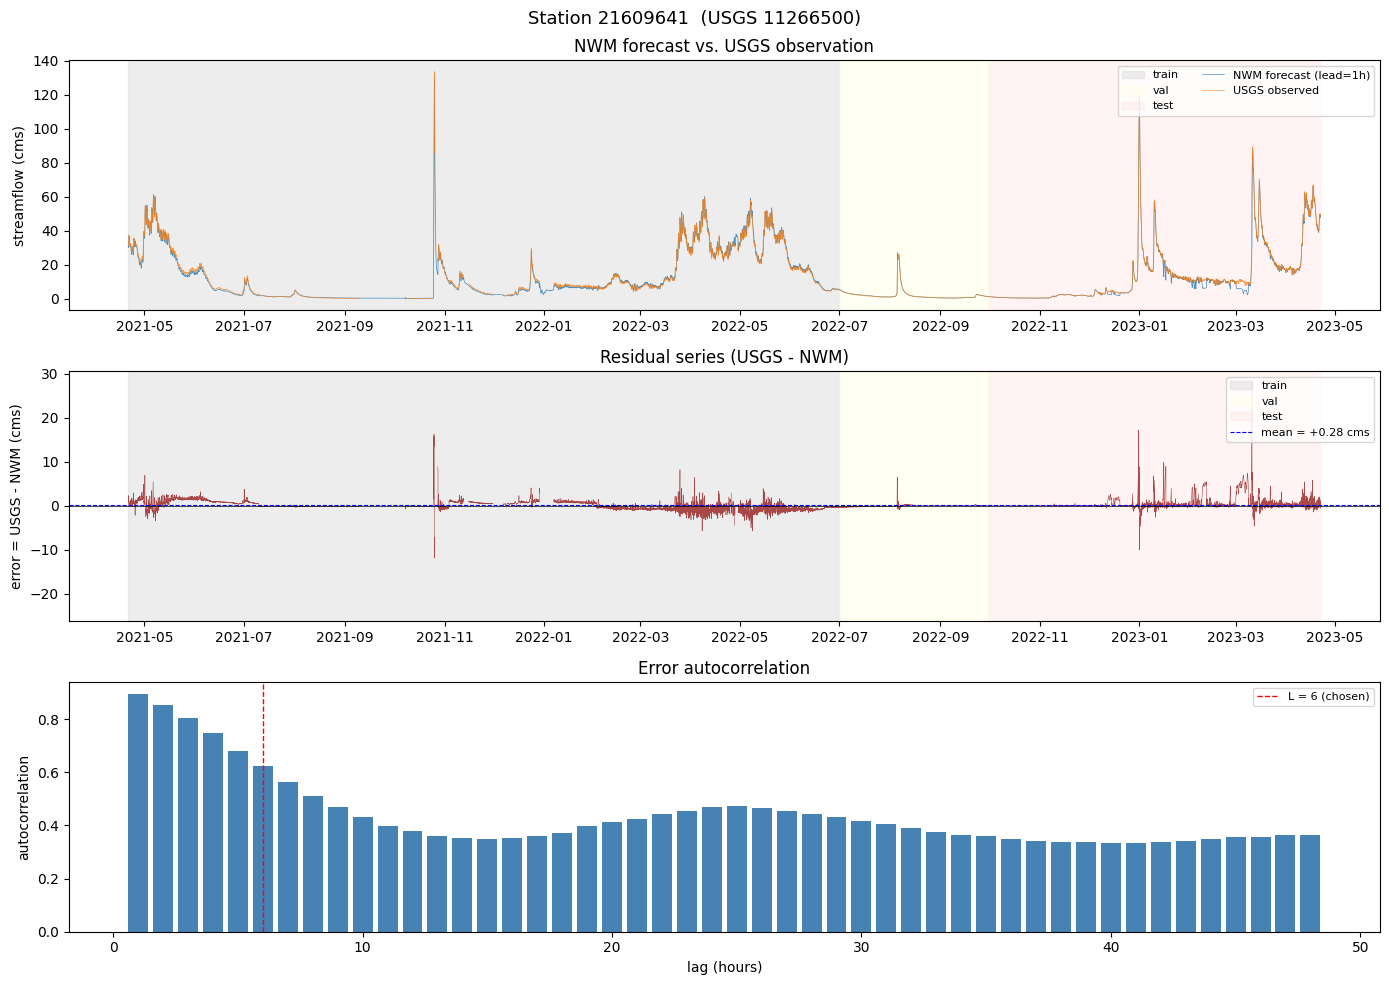

In [9]:
def load_tidy(station_id: str, data_root: Path = Path("data")) -> pd.DataFrame:
    df = pd.read_parquet(data_root / station_id / f"tidy_{station_id}.parquet")
    df = df[df["lead_h"] == 1].set_index("valid_time").sort_index()
    return df[["nwm_q", "usgs_q", "error"]]

def shade_splits(ax) -> None:
    """Shade train / val / test windows. Uses the same boundaries as the split cell."""
    boundaries = [
        ("2021-04-21", "2022-07-01", "lightgray", "train"),
        ("2022-07-01", "2022-10-01", "lightyellow", "val"),
        ("2022-10-01", "2023-04-22", "mistyrose", "test"),
    ]
    for start, end, color, label in boundaries:
        ax.axvspan(pd.Timestamp(start, tz="UTC"),
                   pd.Timestamp(end, tz="UTC"),
                   alpha=0.4, color=color, label=label)

def plot_station(station_id: str, usgs_id: str) -> None:
    df = load_tidy(station_id)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
    fig.suptitle(f"Station {station_id}  (USGS {usgs_id})", fontsize=13)

    # 1. NWM vs USGS overlay
    ax = axes[0]
    shade_splits(ax)
    ax.plot(df.index, df["nwm_q"], lw=0.5, alpha=0.8, label="NWM forecast (lead=1h)")
    ax.plot(df.index, df["usgs_q"], lw=0.5, alpha=0.8, label="USGS observed")
    ax.set_ylabel("streamflow (cms)")
    ax.set_title("NWM forecast vs. USGS observation")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    # 2. Error series
    ax = axes[1]
    shade_splits(ax)
    ax.plot(df.index, df["error"], lw=0.4, color="darkred", alpha=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(df["error"].mean(), color="blue", lw=0.8, ls="--",
               label=f"mean = {df['error'].mean():+.2f} cms")
    ax.set_ylabel("error = USGS - NWM (cms)")
    ax.set_title("Residual series (USGS - NWM)")
    ax.legend(loc="upper right", fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    # 3. Autocorrelation of the error series
    ax = axes[2]
    err = df["error"].dropna().values
    lags = np.arange(1, 49)  # 48 hours
    err_centered = err - err.mean()
    var = (err_centered ** 2).mean()
    acf = np.array([
        (err_centered[:-k] * err_centered[k:]).mean() / var if var > 0 else 0
        for k in lags
    ])
    ax.bar(lags, acf, width=0.8, color="steelblue")
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(6, color="red", lw=1, ls="--", label="L = 6 (chosen)")
    ax.set_xlabel("lag (hours)")
    ax.set_ylabel("autocorrelation")
    ax.set_title("Error autocorrelation")
    ax.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

def report_missing(station_id: str) -> None:
    df = load_tidy(station_id)
    n = len(df)
    n_missing = df["usgs_q"].isna().sum()
    print(f"  station {station_id}: "
          f"{n_missing:,} / {n:,} hours missing USGS ({n_missing/n:.1%})")

def main() -> None:
    stations = {"20380357": "09520500", "21609641": "11266500"}
    print("Missing-data summary (raw, before forward-fill):")
    for sid in stations:
        report_missing(sid)
    print()
    for sid, usgs_id in stations.items():
        plot_station(sid, usgs_id)

main()


## Chronological Train/Validation/Test Split

To prevent temporal leakage, each station’s tidy hourly table is split
chronologically using `valid_time` as the index.

Following the project specification:
- training and validation use April 2021 through September 2022
- testing uses October 2022 through April 2023

The validation set is taken from the most recent portion of the pre-test period,
which follows the common time-series convention of validating on the latest
available training-era data.

In [10]:
STATIONS = ["20380357", "21609641"]

# Date-string slices, NB2 style.  Spec sets test = 2022-10 onward.
TRAIN_RANGE = ("2021-04", "2022-06")
VALID_RANGE = ("2022-07", "2022-09")
TEST_RANGE  = ("2022-10", "2023-04")

def split_station(parquet_path: Path):
    """Read one station's tidy parquet and slice it three ways."""
    df = pd.read_parquet(parquet_path)
    df = df.set_index("valid_time").sort_index()

    train = df.loc[TRAIN_RANGE[0]:TRAIN_RANGE[1]]
    valid = df.loc[VALID_RANGE[0]:VALID_RANGE[1]]
    test  = df.loc[TEST_RANGE[0]:TEST_RANGE[1]]
    return train, valid, test

def report(name: str, df: pd.DataFrame) -> None:
    if df.empty:
        print(f"  {name:6s}: EMPTY")
        return
    n_days = df.index.normalize().nunique()
    print(f"  {name:6s}: {len(df):>7,} rows | "
          f"{df.index.min()}  ->  {df.index.max()} | "
          f"{n_days} unique days")

def main() -> None:
    data_root = Path("data")
    for sid in STATIONS:
        in_path = data_root / sid / f"tidy_{sid}.parquet"
        print(f"\n{'='*70}\nstation {sid}\n{'='*70}")

        train, valid, test = split_station(in_path)
        report("train", train)
        report("valid", valid)
        report("test",  test)

        for name, part in [("train", train), ("valid", valid), ("test", test)]:
            out = data_root / sid / f"{name}_{sid}.parquet"
            part.reset_index().to_parquet(out)
        print(f"  wrote: train_/valid_/test_{sid}.parquet")

main()



station 20380357
  train : 188,181 rows | 2021-04-21 01:00:00+00:00  ->  2022-06-30 23:00:00+00:00 | 436 unique days
  valid :  39,744 rows | 2022-07-01 00:00:00+00:00  ->  2022-09-30 23:00:00+00:00 | 92 unique days
  test  :  87,864 rows | 2022-10-01 00:00:00+00:00  ->  2023-04-22 17:00:00+00:00 | 204 unique days
  wrote: train_/valid_/test_20380357.parquet

station 21609641
  train : 188,181 rows | 2021-04-21 01:00:00+00:00  ->  2022-06-30 23:00:00+00:00 | 436 unique days
  valid :  39,744 rows | 2022-07-01 00:00:00+00:00  ->  2022-09-30 23:00:00+00:00 | 92 unique days
  test  :  87,864 rows | 2022-10-01 00:00:00+00:00  ->  2023-04-22 17:00:00+00:00 | 204 unique days
  wrote: train_/valid_/test_21609641.parquet


## Sequencing Window and Dataset Construction

This section converts each station’s hourly time series into fixed-length input
and target sequences for recurrent neural network training.

The modeling setup is:
- input window length `L = 6` hours
- forecast horizon `H = 18` hours
- input features `[error, nwm_q, usgs_q]` at `lead_h = 1`
- target = the next 18 hourly residual values

Inputs are normalized using mean and standard deviation computed on the training
split only. Targets remain in raw `cms`, so predictions are directly interpretable
as forecast corrections in physical units.

In [11]:


# Hyperparameters from milestone notes (Han & Morrison sensitivity analysis).
L = 6              # input window length (hours)
H = 18             # forecast horizon (hours)
BATCH_SIZE = 128

FEATURE_COLS = ["error", "nwm_q", "usgs_q"]
TARGET_COL = "error"

STATIONS = ["20380357", "21609641"]

# ---------- features -------------------------------------------------------- #

def prepare_features(split_df: pd.DataFrame) -> pd.DataFrame:
    """
    Long-format split -> hourly wide frame indexed by valid_time.

    Keeps only the lead_h=1 row per valid_time (one observation per hour),
    forward-fills any missing usgs_q (and the derived `error`) so the
    series is continuous for windowing.
    """
    df = split_df[split_df["lead_h"] == 1].copy()
    df = df.set_index("valid_time").sort_index()
    df = df[FEATURE_COLS]

    # Forward-fill the USGS gaps (~6% on station 2). Same semantics as
    # NB2's handling of intermittent missing values: keep cadence, accept
    # a small amount of repeated information rather than break the grid.
    df = df.ffill().bfill()
    return df

# ---------- normalization (fit on train only) ------------------------------ #

def fit_norm(train_features: pd.DataFrame):
    """Per-column mean/std from training features only."""
    mean = train_features.mean()
    std = train_features.std().replace(0.0, 1.0)
    return mean.values, std.values


def apply_norm(features: pd.DataFrame, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return ((features.values - mean) / std).astype(np.float32)

# ---------- seq2seq targets ----------------------------------------------- #

def build_seq2seq_targets(series: np.ndarray, L: int, H: int) -> np.ndarray:
    """
    Build 2D target array of shape (n_windows, H) where row i corresponds
    to the input window data[i:i+L] and contains the next H values:

        targets[i] = series[i+L : i+L+H]
    """
    N = len(series)
    n_windows = N - L - H + 1
    if n_windows <= 0:
        raise ValueError(f"Series too short: N={N}, need at least L+H={L+H}")
    out = np.empty((n_windows, H), dtype=np.float32)
    for h in range(H):
        out[:, h] = series[L + h : N - H + 1 + h]
    return out

# ---------- tf.data dataset ----------------------------------------------- #

def make_dataset(
    features: np.ndarray,
    targets: np.ndarray,
    L: int,
    H: int,
    batch_size: int,
    shuffle: bool,
    seed: int = 42,
) -> tf.data.Dataset:
    """
    NB2's high-level recipe: timeseries_dataset_from_array with explicit
    targets aligned to the END of each input window.

    `features[:-H]` truncates so the last window's 18-hour target lives
    inside the data. Windows are shuffled (per NB2: fine because we
    shuffle WHOLE windows, each of which preserves temporal order).
    """
    return tf.keras.utils.timeseries_dataset_from_array(
        data=features[:-H],
        targets=targets,
        sequence_length=L,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=seed,
    )

# ---------- per-station pipeline ------------------------------------------ #

def build_station_datasets(station_id: str, data_root: Path = Path("data")):
    """Return (train_ds, valid_ds, test_ds, mean, std) for one station."""
    split_paths = {
        s: data_root / station_id / f"{s}_{station_id}.parquet"
        for s in ("train", "valid", "test")
    }
    splits = {s: pd.read_parquet(p) for s, p in split_paths.items()}
    feats = {s: prepare_features(df) for s, df in splits.items()}

    mean, std = fit_norm(feats["train"])

    datasets = {}
    for name, df in feats.items():
        x = apply_norm(df, mean, std)                      # (N, n_features)
        y_series = df[TARGET_COL].values.astype(np.float32)  # un-normalized error
        # Note: targets are RAW error in cms, not normalized -- so the model
        # learns to output cms directly. (Han & Morrison does this too.)
        targets = build_seq2seq_targets(y_series, L=L, H=H)
        ds = make_dataset(
            features=x,
            targets=targets,
            L=L,
            H=H,
            batch_size=BATCH_SIZE,
            shuffle=(name == "train"),
        )
        datasets[name] = ds

    return datasets, mean, std

# ---------- reporting ----------------------------------------------------- #

def report_station(station_id: str) -> None:
    print(f"\n{'='*70}\nstation {station_id}\n{'='*70}")
    datasets, mean, std = build_station_datasets(station_id)

    print(f"\n  hyperparameters:  L={L}  H={H}  batch={BATCH_SIZE}")
    print(f"  feature columns:  {FEATURE_COLS}")
    print(f"  target column:    {TARGET_COL}  (raw cms, not normalized)")
    print(f"\n  train norm stats (mean / std):")
    for col, m, s in zip(FEATURE_COLS, mean, std):
        print(f"    {col:8s}  mean={m:8.3f}   std={s:8.3f}")

    print(f"\n  dataset shapes:")
    for name, ds in datasets.items():
        x_batch, y_batch = next(iter(ds))
        n_batches = sum(1 for _ in ds)
        print(f"    {name:6s}  batches={n_batches:>4}   "
              f"x={tuple(x_batch.shape)}   y={tuple(y_batch.shape)}")

def main() -> None:
    for sid in STATIONS:
        report_station(sid)

main()



station 20380357

  hyperparameters:  L=6  H=18  batch=128
  feature columns:  ['error', 'nwm_q', 'usgs_q']
  target column:    error  (raw cms, not normalized)

  train norm stats (mean / std):
    error     mean=  -4.183   std=   5.547
    nwm_q     mean=   4.452   std=   5.545
    usgs_q    mean=   0.270   std=   0.132

  dataset shapes:
    train   batches=  82   x=(128, 6, 3)   y=(128, 18)
    valid   batches=  18   x=(128, 6, 3)   y=(128, 18)
    test    batches=  38   x=(128, 6, 3)   y=(128, 18)

station 21609641

  hyperparameters:  L=6  H=18  batch=128
  feature columns:  ['error', 'nwm_q', 'usgs_q']
  target column:    error  (raw cms, not normalized)

  train norm stats (mean / std):
    error     mean=   0.212   std=   1.513
    nwm_q     mean=  13.158   std=  14.573
    usgs_q    mean=  13.374   std=  14.441

  dataset shapes:
    train   batches=  82   x=(128, 6, 3)   y=(128, 18)
    valid   batches=  18   x=(128, 6, 3)   y=(128, 18)
    test    batches=  38   x=(128, 6,

In [8]:
"""
Persistence baseline: use NWM forecast unchanged, i.e., predicted error = 0
at every lead time. The "thing to beat" per milestone Part H.

Saves predictions in the same shape as DL model predictions: (n_windows, H).
Output: data/<station>/preds_persistence_<station>.npy

Relies on names defined in the earlier windows cell:
  L, H, STATIONS, prepare_features
"""

from pathlib import Path
import numpy as np
import pandas as pd


def predict_persistence(station_id: str, data_root: Path = Path("data")) -> np.ndarray:
    test_split = pd.read_parquet(data_root / station_id / f"test_{station_id}.parquet")
    test_feats = prepare_features(test_split)
    n_windows = len(test_feats) - L - H + 1
    return np.zeros((n_windows, H), dtype=np.float32)


def main() -> None:
    data_root = Path("data")
    for sid in STATIONS:
        out_path = data_root / sid / f"preds_persistence_{sid}.npy"
        preds = predict_persistence(sid, data_root)
        np.save(out_path, preds)
        print(f"  station {sid}: saved {out_path.name}  shape={preds.shape}")


if __name__ == "__main__":
    main()

  station 20380357: saved preds_persistence_20380357.npy  shape=(4850, 18)
  station 21609641: saved preds_persistence_21609641.npy  shape=(4850, 18)


In [9]:
"""
DL training: GRU(32) and LSTM stacked, per station.

Architectures and hyperparameters from milestone Part H, traceable to NB2
and Han & Morrison:

  * Model 1 -- gru:           GRU(32) -> Dense(18)
                              NB2 model zoo entry 5 (multi-step Dense head).
  * Model 2 -- lstm_stacked:  LSTM(32, return_sequences=True) -> LSTM(32) -> Dense(18)
                              NB2 model zoo entry 3 (deep RNN), with LSTM cells.

Compile / train (milestone Part C.10 + Part H):
  * Loss: Huber (robust to flood-peak outliers)
  * Optimizer: Adam(lr=1e-3, clipnorm=1.0)
  * Metric: MAE
  * Callbacks: EarlyStopping(val_mae, patience=20, restore_best_weights),
               ReduceLROnPlateau(factor=0.5, patience=5)
  * fit_and_evaluate convention from NB2.
  * clear_session + set_seed(42) before each model build.

Saves per (station, model):
  data/<station>/<model>_<station>.keras       trained model
  data/<station>/preds_<model>_<station>.npy   test-set predictions, shape (n_windows, H)

Relies on names defined in earlier cells:
  L, H, FEATURE_COLS, STATIONS, build_station_datasets
"""

from pathlib import Path
import numpy as np
import tensorflow as tf

EPOCHS = 200
LEARNING_RATE = 1e-3
GRU_UNITS = 32       # paper's optimum
LSTM_UNITS = 32      # paper's optimum


# ---------- model builders ----------------------------------------------- #

def _seed_and_clear() -> None:
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)


def build_gru(L: int, n_features: int, H: int) -> tf.keras.Model:
    """NB2 entry 5: single recurrent layer + multi-step Dense head."""
    _seed_and_clear()
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L, n_features)),
        tf.keras.layers.GRU(GRU_UNITS),
        tf.keras.layers.Dense(H),
    ])


def build_lstm_stacked(L: int, n_features: int, H: int) -> tf.keras.Model:
    """NB2 entry 3 (deep RNN), with LSTM cells per milestone Part H."""
    _seed_and_clear()
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L, n_features)),
        tf.keras.layers.LSTM(LSTM_UNITS, return_sequences=True),
        tf.keras.layers.LSTM(LSTM_UNITS),
        tf.keras.layers.Dense(H),
    ])


MODELS = {
    "gru": build_gru,
    "lstm_stacked": build_lstm_stacked,
}


# ---------- compile / callbacks / fit ------------------------------------ #

def compile_model(model: tf.keras.Model, lr: float = LEARNING_RATE) -> None:
    model.compile(
        loss=tf.keras.losses.Huber(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        metrics=["mae"],
    )


def make_callbacks() -> list:
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_mae", patience=20, restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae", factor=0.5, patience=5,
        ),
    ]


def fit_and_evaluate(model, train_ds, valid_ds, epochs=EPOCHS):
    history = model.fit(
        train_ds, validation_data=valid_ds, epochs=epochs,
        callbacks=make_callbacks(), verbose=2,
    )
    val_loss, val_mae = model.evaluate(valid_ds, verbose=0)
    return history, val_mae


# ---------- per (station, model) experiment ------------------------------ #

def train_one(station_id: str, model_name: str, data_root: Path = Path("data")):
    print(f"\n{'-'*70}\n  {station_id}  /  {model_name}\n{'-'*70}")

    datasets, _, _ = build_station_datasets(station_id, data_root)
    n_features = len(FEATURE_COLS)

    model = MODELS[model_name](L=L, n_features=n_features, H=H)
    compile_model(model)
    model.summary(line_length=70)

    _, val_mae = fit_and_evaluate(model, datasets["train"], datasets["valid"])
    test_loss, test_mae = model.evaluate(datasets["test"], verbose=0)

    model.save(data_root / station_id / f"{model_name}_{station_id}.keras")
    preds = model.predict(datasets["test"], verbose=0)
    np.save(data_root / station_id / f"preds_{model_name}_{station_id}.npy", preds)

    print(f"  val_mae:  {val_mae:.4f} cms")
    print(f"  test_mae: {test_mae:.4f} cms")
    return val_mae, test_mae


# ---------- main --------------------------------------------------------- #

def main() -> None:
    gpus = tf.config.list_physical_devices("GPU")
    print(f"GPUs visible: {len(gpus)}  ({'CPU only' if not gpus else gpus})")

    summary = {}
    for sid in STATIONS:
        print(f"\n{'='*70}\nstation {sid}\n{'='*70}")
        for model_name in MODELS:
            val_mae, test_mae = train_one(sid, model_name)
            summary[(sid, model_name)] = (val_mae, test_mae)

    print(f"\n{'='*70}\nfinal MAE summary (cms, lower=better)\n{'='*70}")
    print(f"  {'station':<12} {'model':<14} {'val_mae':>10} {'test_mae':>10}")
    for (sid, name), (vm, tm) in summary.items():
        print(f"  {sid:<12} {name:<14} {vm:>10.4f} {tm:>10.4f}")


if __name__ == "__main__":
    main()

GPUs visible: 1  ([PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')])

station 20380357

----------------------------------------------------------------------
  20380357  /  gru
----------------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ gru (GRU)                    │ (None, 32)            │       3,552 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense (Dense)                │ (None, 18)            │         594 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 4,146 (16.20 KB)

 Trainable params: 4,146 (16.20 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ lstm (LSTM)                  │ (None, 6, 32)         │       4,608 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ lstm_1 (LSTM)                │ (None, 32)            │       8,320 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense (Dense)                │ (None, 18)            │         594 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 13,522 (52.82 KB)

 Trainable params: 13,522 (52.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
82/82 - 4s - 49ms/step - loss: 0.3632 - mae: 0.6440 - val_loss: 0.0229 - val_mae: 0.1152 - learning_rate: 0.0010
Epoch 2/200
82/82 - 2s - 26ms/step - loss: 0.2507 - mae: 0.4394 - val_loss: 0.0221 - val_mae: 0.1032 - learning_rate: 0.0010
Epoch 3/200
82/82 - 3s - 35ms/step - loss: 0.2334 - mae: 0.4129 - val_loss: 0.0191 - val_mae: 0.0532 - learning_rate: 0.0010
Epoch 4/200
82/82 - 2s - 23ms/step - loss: 0.2229 - mae: 0.3954 - val_loss: 0.0209 - val_mae: 0.0840 - learning_rate: 0.0010
Epoch 5/200
82/82 - 2s - 23ms/step - loss: 0.2159 - mae: 0.3879 - val_loss: 0.0197 - val_mae: 0.0732 - learning_rate: 0.0010
Epoch 6/200
82/82 - 2s - 23ms/step - loss: 0.2120 - mae: 0.3822 - val_loss: 0.0195 - val_mae: 0.0566 - learning_rate: 0.0010
Epoch 7/200
82/82 - 2s - 25ms/step - loss: 0.2082 - mae: 0.3774 - val_loss: 0.0186 - val_mae: 0.0519 - learning_rate: 0.0010
Epoch 8/200
82/82 - 2s - 26ms/step - loss: 0.2040 - mae: 0.3716 - val_loss: 0.0177 - val_mae: 0.0501 - learning_rate: 0.0010



station 20380357
  wrote: data/20380357/metrics_20380357.csv


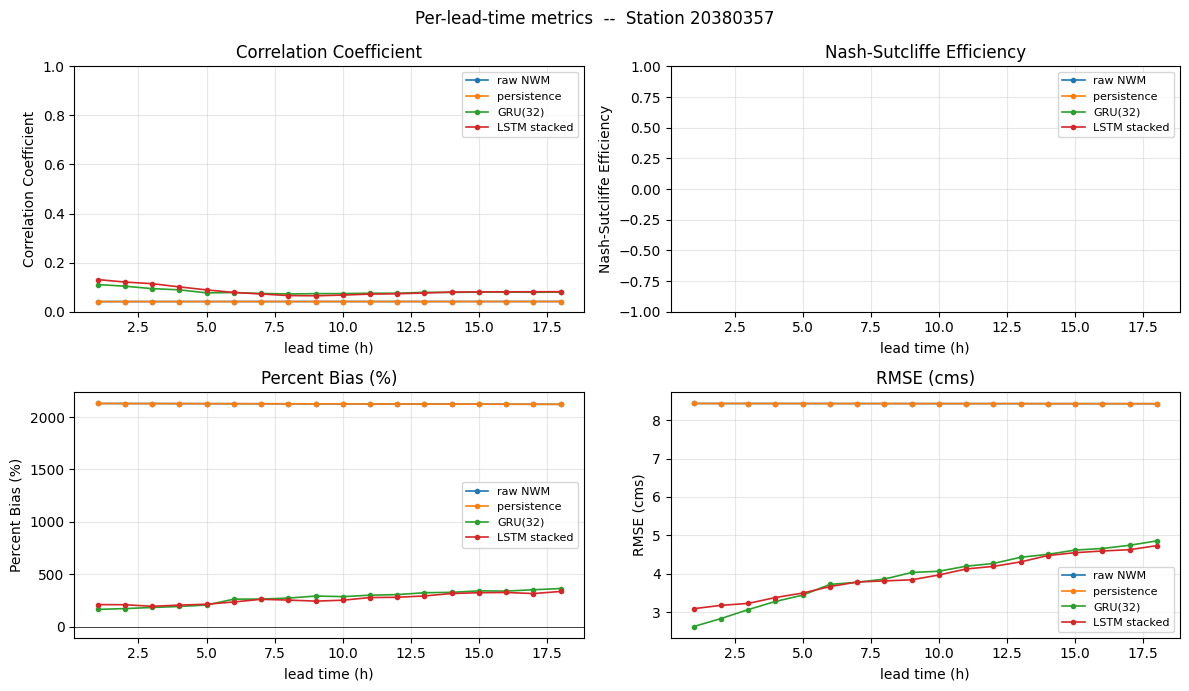

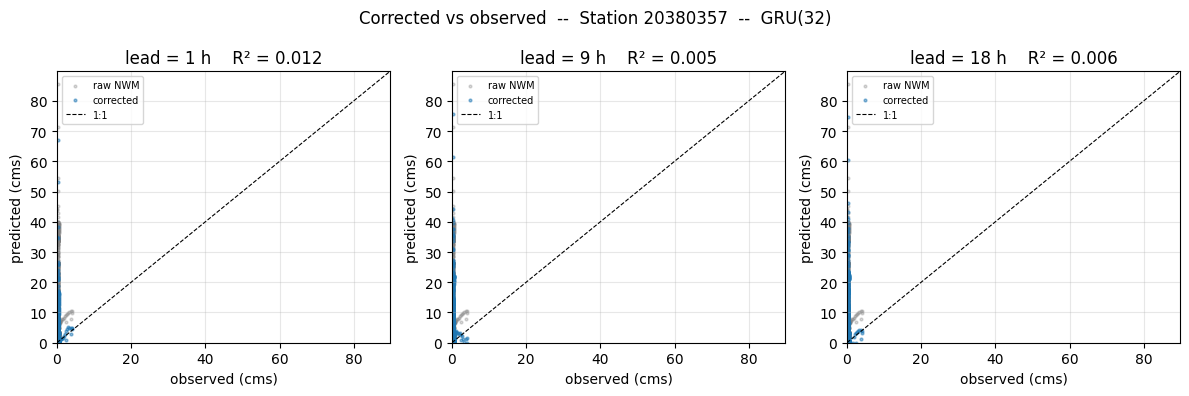

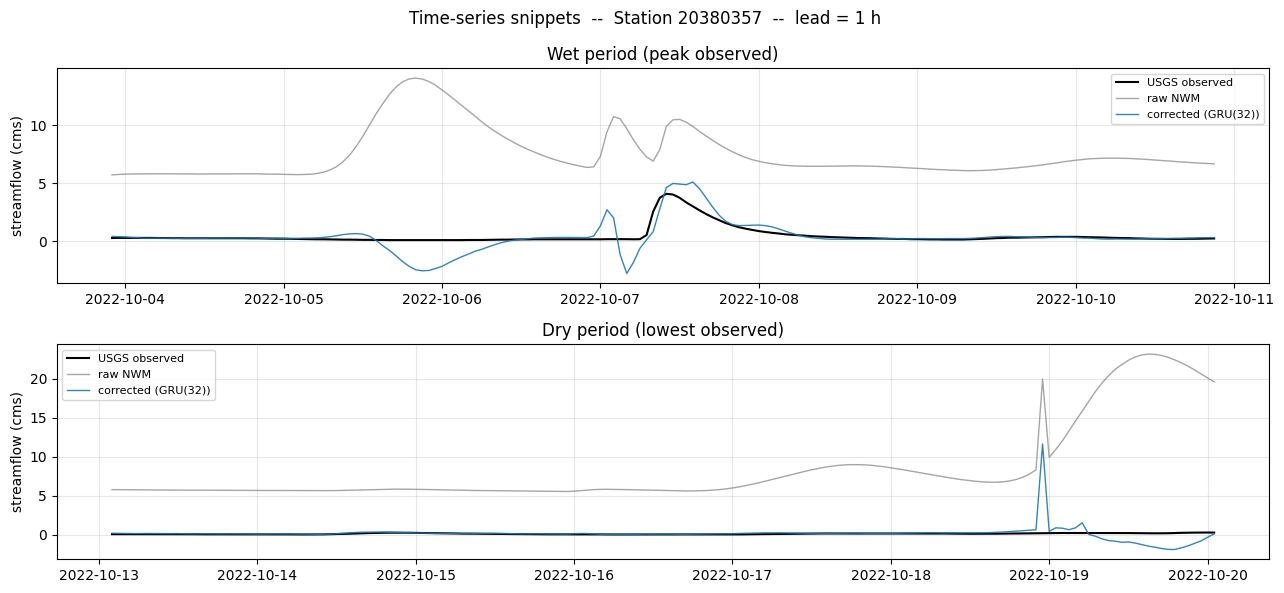


station 21609641
  wrote: data/21609641/metrics_21609641.csv


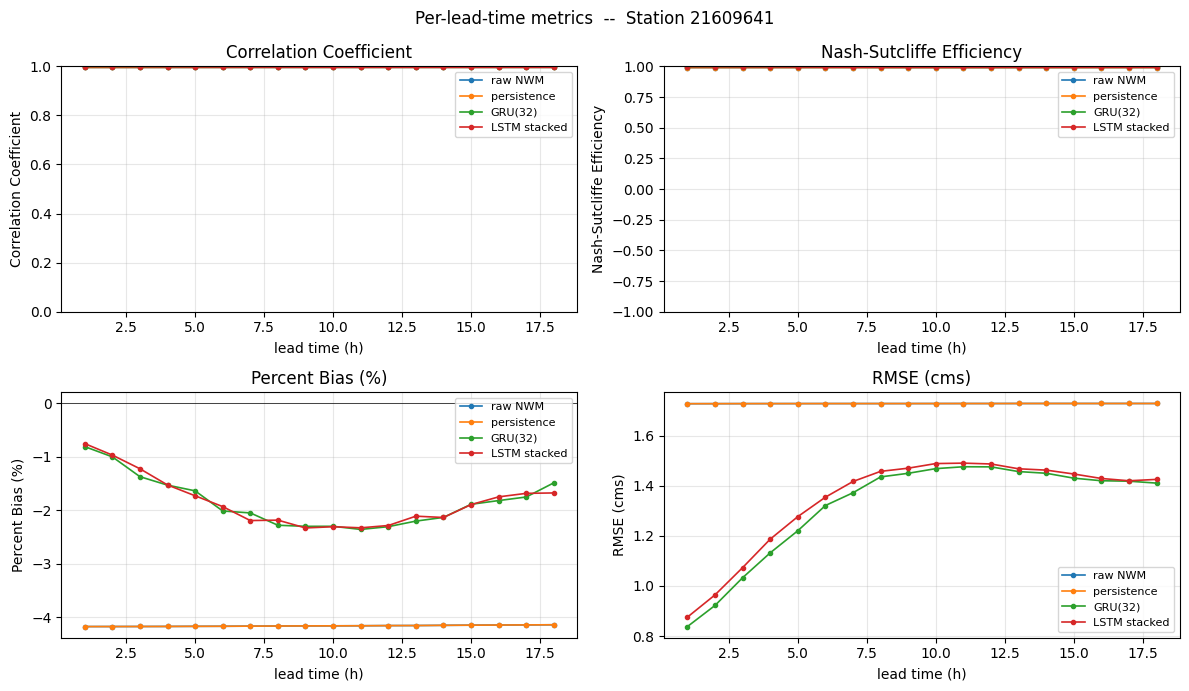

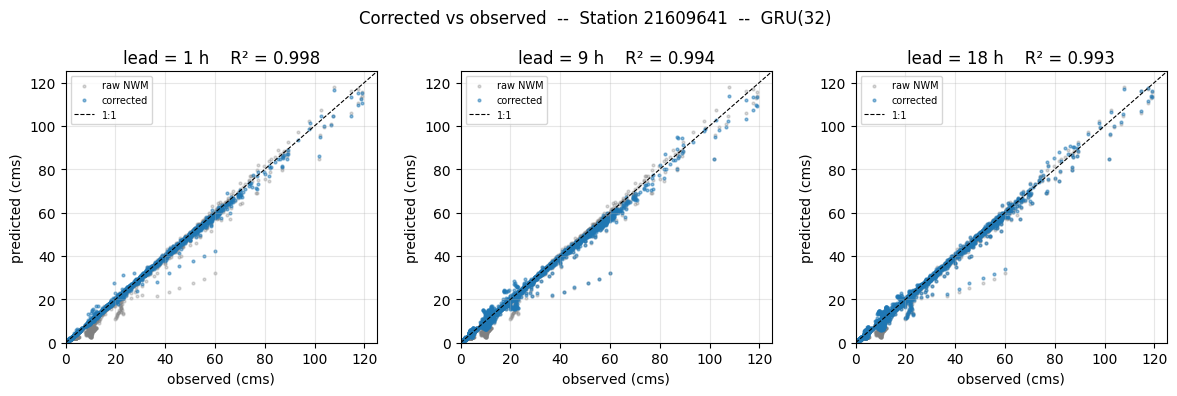

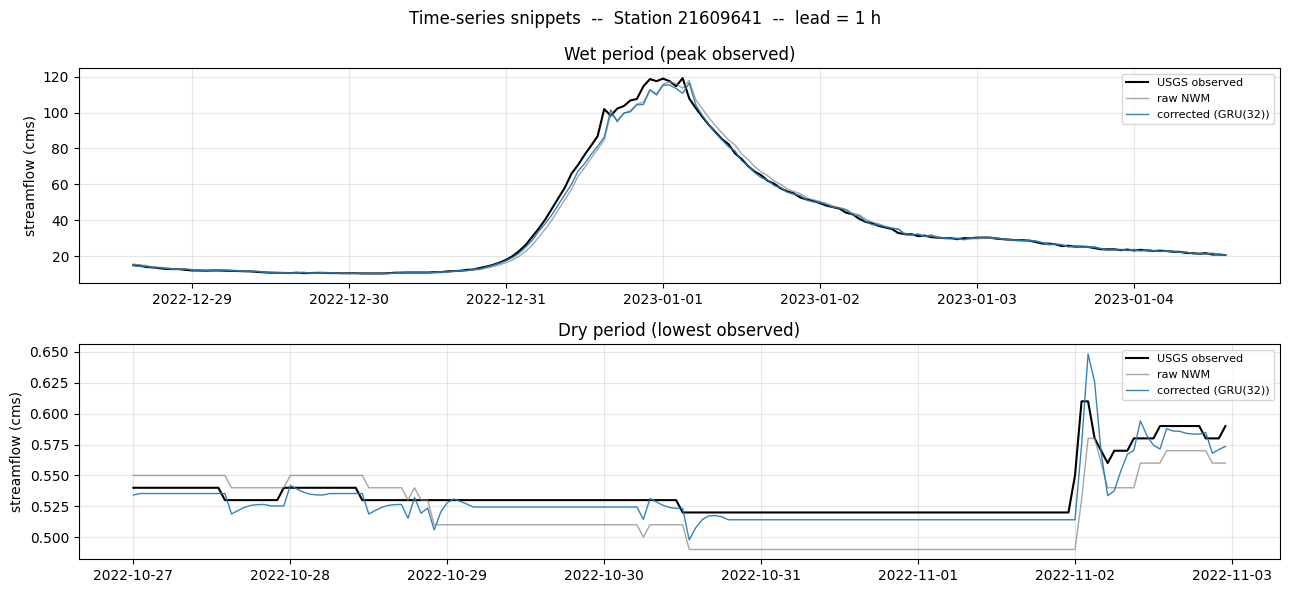


mean metrics across leads 1..18
                           cc        nse      pbias    rmse
station  model                                             
20380357 gru           0.0819  -525.7335   274.2815  3.9436
         lstm_stacked  0.0851  -521.5809   263.1065  3.9476
         nwm_raw       0.0415 -2341.1470  2125.8113  8.4297
         persistence   0.0415 -2341.1470  2125.8113  8.4297
21609641 gru           0.9972     0.9937    -1.8425  1.3180
         lstm_stacked  0.9971     0.9935    -1.8298  1.3438
         nwm_raw       0.9953     0.9895    -4.1556  1.7276
         persistence   0.9953     0.9895    -4.1556  1.7276

  --- lead = 1 h ---
                           cc        nse      pbias    rmse
station  model                                             
20380357 nwm_raw       0.0413 -2341.1768  2129.5703  8.4325
         persistence   0.0413 -2341.1768  2129.5703  8.4325
         gru           0.1108  -226.1031   163.5537  2.6258
         lstm_stacked  0.1310  -313.7250   20

In [10]:
"""
Hydrologic evaluation: per-lead-time metrics + plots for runoff.

Per milestone Part G.5 + project spec section 4.3:
  * CC    -- Pearson correlation
  * NSE   -- Nash-Sutcliffe Efficiency
  * PBIAS -- percent bias  (positive = overestimate)
  * RMSE  -- root mean squared error in cms
  * R^2   -- on the scatter plot of corrected vs observed

All four computed PER LEAD TIME (h=1..18) for:
  * raw NWM (the thing to beat, per spec section 4.3)
  * persistence baseline (= raw NWM, included as sanity check)
  * GRU
  * LSTM stacked

The corrected forecast for each model is reconstructed as:
    corrected_q = nwm_q + predicted_error
since all DL models predict the residual, not the raw runoff.

Plots produced per station:
  1. Per-lead-time line plots of CC, NSE, PBIAS, RMSE
     (NWM monotone-degrading curve with our DL models on top)
  2. Scatter plot of corrected vs observed at lead_h=1, 9, 18
  3. Two time-series snippets (one dry period, one wet period) showing
     NWM, observed, and best-DL corrected.

Outputs:
  data/<station>/metrics_<station>.csv  (long-format, all rows)
  Console: mean metrics across leads per (station, model)

Relies on names defined in earlier cells:
  L, H, STATIONS, prepare_features, build_seq2seq_targets
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

MODEL_NAMES = ["persistence", "gru", "lstm_stacked"]
PRETTY = {
    "nwm_raw":      "raw NWM",
    "persistence":  "persistence",
    "gru":          "GRU(32)",
    "lstm_stacked": "LSTM stacked",
}


# ---------- metrics ------------------------------------------------------- #

def cc(obs: np.ndarray, sim: np.ndarray) -> float:
    o, s = obs - obs.mean(), sim - sim.mean()
    denom = np.sqrt((o**2).sum() * (s**2).sum())
    return float((o * s).sum() / denom) if denom > 0 else float("nan")


def nse(obs: np.ndarray, sim: np.ndarray) -> float:
    denom = ((obs - obs.mean()) ** 2).sum()
    return float(1.0 - ((obs - sim) ** 2).sum() / denom) if denom > 0 else float("nan")


def pbias(obs: np.ndarray, sim: np.ndarray) -> float:
    s = obs.sum()
    return float(100.0 * (sim - obs).sum() / s) if s != 0 else float("nan")


def rmse(obs: np.ndarray, sim: np.ndarray) -> float:
    return float(np.sqrt(((obs - sim) ** 2).mean()))


def r2(obs: np.ndarray, sim: np.ndarray) -> float:
    return cc(obs, sim) ** 2


# ---------- per-station evaluation --------------------------------------- #

def build_truth(test_features: pd.DataFrame):
    """(n_windows, H) grids of NWM forecast and USGS observation."""
    nwm = build_seq2seq_targets(test_features["nwm_q"].values.astype(np.float32), L=L, H=H)
    obs = build_seq2seq_targets(test_features["usgs_q"].values.astype(np.float32), L=L, H=H)
    return nwm, obs


def evaluate_station(station_id: str, data_root: Path = Path("data")) -> tuple:
    print(f"\n{'='*70}\nstation {station_id}\n{'='*70}")

    test_split = pd.read_parquet(data_root / station_id / f"test_{station_id}.parquet")
    test_feats = prepare_features(test_split)
    nwm_grid, obs_grid = build_truth(test_feats)

    rows = []
    grids = {"nwm_raw": nwm_grid}  # store corrected grids for plotting

    # raw NWM
    for h in range(H):
        o, s = obs_grid[:, h], nwm_grid[:, h]
        rows.append({"station": station_id, "model": "nwm_raw", "lead_h": h + 1,
                     "cc": cc(o, s), "nse": nse(o, s),
                     "pbias": pbias(o, s), "rmse": rmse(o, s)})

    # each model's predicted error -> corrected forecast
    for name in MODEL_NAMES:
        path = data_root / station_id / f"preds_{name}_{station_id}.npy"
        if not path.exists():
            print(f"  [skip] {path.name} not found")
            continue
        err_pred = np.load(path)
        if err_pred.shape != obs_grid.shape:
            print(f"  [skip] {name}: shape {err_pred.shape} != {obs_grid.shape}")
            continue
        corrected = nwm_grid + err_pred
        grids[name] = corrected
        for h in range(H):
            o, s = obs_grid[:, h], corrected[:, h]
            rows.append({"station": station_id, "model": name, "lead_h": h + 1,
                         "cc": cc(o, s), "nse": nse(o, s),
                         "pbias": pbias(o, s), "rmse": rmse(o, s)})

    df = pd.DataFrame(rows)
    out = data_root / station_id / f"metrics_{station_id}.csv"
    df.to_csv(out, index=False)
    print(f"  wrote: {out}")

    return df, grids, obs_grid, test_feats


# ---------- plots --------------------------------------------------------- #

def plot_per_lead_metrics(df: pd.DataFrame, station_id: str) -> None:
    metrics = [("cc", "Correlation Coefficient", (0, 1)),
               ("nse", "Nash-Sutcliffe Efficiency", (-1, 1)),
               ("pbias", "Percent Bias (%)", None),
               ("rmse", "RMSE (cms)", None)]
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    fig.suptitle(f"Per-lead-time metrics  --  Station {station_id}", fontsize=12)

    for ax, (col, title, ylim) in zip(axes.flat, metrics):
        for model in df["model"].unique():
            sub = df[df["model"] == model]
            ax.plot(sub["lead_h"], sub[col], marker="o", ms=3, lw=1.2,
                    label=PRETTY.get(model, model))
        if col == "pbias":
            ax.axhline(0, color="black", lw=0.5)
        ax.set_xlabel("lead time (h)")
        ax.set_ylabel(title)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_scatter(grids: dict, obs_grid: np.ndarray, station_id: str,
                 leads=(1, 9, 18)) -> None:
    """
    Scatter plot of best-DL-model's corrected forecast vs USGS observation
    at chosen lead times. NWM raw shown as gray points behind.
    """
    # pick best DL model = lowest mean RMSE
    best_name = None
    best_rmse_mean = np.inf
    for name, grid in grids.items():
        if name in ("nwm_raw", "persistence"):
            continue
        m = np.mean([rmse(obs_grid[:, h], grid[:, h]) for h in range(H)])
        if m < best_rmse_mean:
            best_rmse_mean, best_name = m, name
    if best_name is None:
        print("  [scatter] no DL model available")
        return

    fig, axes = plt.subplots(1, len(leads), figsize=(4 * len(leads), 4))
    if len(leads) == 1:
        axes = [axes]
    fig.suptitle(f"Corrected vs observed  --  Station {station_id}  --  {PRETTY[best_name]}",
                 fontsize=12)

    for ax, lead in zip(axes, leads):
        h = lead - 1
        o = obs_grid[:, h]
        nwm = grids["nwm_raw"][:, h]
        sim = grids[best_name][:, h]
        lim = max(o.max(), nwm.max(), sim.max()) * 1.05

        ax.scatter(o, nwm, s=4, alpha=0.3, color="gray", label="raw NWM")
        ax.scatter(o, sim, s=4, alpha=0.5, color="C0", label="corrected")
        ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="1:1")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel("observed (cms)")
        ax.set_ylabel("predicted (cms)")
        ax.set_title(f"lead = {lead} h    R² = {r2(o, sim):.3f}")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_timeseries_snippets(grids: dict, obs_grid: np.ndarray,
                             test_feats: pd.DataFrame, station_id: str) -> None:
    """
    Two snippets at lead_h = 1: one wet period (highest observed),
    one dry period (lowest observed). NWM, observed, and best DL.
    """
    best_name = None
    best_rmse_mean = np.inf
    for name, grid in grids.items():
        if name in ("nwm_raw", "persistence"):
            continue
        m = np.mean([rmse(obs_grid[:, h], grid[:, h]) for h in range(H)])
        if m < best_rmse_mean:
            best_rmse_mean, best_name = m, name
    if best_name is None:
        return

    # window-index -> valid_time of the FIRST forecast hour (lead=1)
    n_windows = obs_grid.shape[0]
    valid_times = test_feats.index[L : L + n_windows]
    o_lead1 = obs_grid[:, 0]
    nwm_lead1 = grids["nwm_raw"][:, 0]
    sim_lead1 = grids[best_name][:, 0]

    # find a 7-day wet window (centered on max obs) and a 7-day dry window
    span = 24 * 7  # one week of windows (which are hourly-spaced)
    wet_center = int(np.argmax(o_lead1))
    dry_center = int(np.argmin(o_lead1))

    fig, axes = plt.subplots(2, 1, figsize=(13, 6))
    fig.suptitle(f"Time-series snippets  --  Station {station_id}  --  lead = 1 h",
                 fontsize=12)

    for ax, center, label in [(axes[0], wet_center, "Wet period (peak observed)"),
                              (axes[1], dry_center, "Dry period (lowest observed)")]:
        lo = max(0, center - span // 2)
        hi = min(n_windows, center + span // 2)
        idx = slice(lo, hi)
        ax.plot(valid_times[idx], o_lead1[idx], "k", lw=1.5, label="USGS observed")
        ax.plot(valid_times[idx], nwm_lead1[idx], color="gray", lw=1, alpha=0.7,
                label="raw NWM")
        ax.plot(valid_times[idx], sim_lead1[idx], color="C0", lw=1, alpha=0.9,
                label=f"corrected ({PRETTY[best_name]})")
        ax.set_ylabel("streamflow (cms)")
        ax.set_title(label)
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ---------- summary printing --------------------------------------------- #

def print_summary(df_all: pd.DataFrame) -> None:
    print(f"\n{'='*70}\nmean metrics across leads 1..18\n{'='*70}")
    summary = (
        df_all.groupby(["station", "model"])[["cc", "nse", "pbias", "rmse"]]
        .mean()
        .round(4)
    )
    print(summary.to_string())


def print_lead1_lead18(df_all: pd.DataFrame) -> None:
    """Like the Han & Morrison Table 5: short vs long lead time."""
    for lead in (1, 18):
        print(f"\n  --- lead = {lead} h ---")
        sub = (df_all[df_all["lead_h"] == lead]
               .set_index(["station", "model"])
               [["cc", "nse", "pbias", "rmse"]]
               .round(4))
        print(sub.to_string())


def main() -> None:
    parts = []
    for sid in [s for s in STATIONS]:  # STATIONS may be dict or list
        df_s, grids, obs_grid, test_feats = evaluate_station(sid)
        parts.append(df_s)
        plot_per_lead_metrics(df_s, sid)
        plot_scatter(grids, obs_grid, sid)
        plot_timeseries_snippets(grids, obs_grid, test_feats, sid)

    df_all = pd.concat(parts, ignore_index=True)
    print_summary(df_all)
    print_lead1_lead18(df_all)


if __name__ == "__main__":
    main()